## Objective

This notebook performs a structured data quality assessment of the raw credit application dataset prior to downstream analytical use.

The assessment is organized by core data quality dimensions and is designed to identify, quantify, and document issues that may affect analysis reliability and governance compliance:

- **Completeness** – missing values and empty-string placeholders  
- **Consistency** – inconsistent formats, categorical encodings, and schema variations  
- **Validity** – impossible, malformed, or out-of-range values  
- **Uniqueness** – duplicate records and conflicting identifiers  
- **Accuracy** – values that may be internally inconsistent or analytically unreliable

For each identified issue, we quantify the number and percentage of affected records, assess potential downstream impact, and define a remediation strategy. Remediation is then implemented and verified in the subsequent section of the notebook.

The outcome of this process is a cleaned and standardized dataset suitable for reliable fairness analysis and governance evaluation.

In [2]:
# Import of Standard libraries
import json
import copy
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Display settings (ensuring all columns are visible)
pd.set_option("display.max_columns", None)

# Define data path
DATA_PATH = Path("../data/raw_credit_applications.json")

In [2]:
# Load raw JSON file
with open(DATA_PATH, "r") as f:
    records = json.load(f)

print(f"Total applications loaded: {len(records)}")

Total applications loaded: 502


In [3]:
# Inspect structure of first record
print("Top-level fields in first application record:")
print(records[0].keys())

Top-level fields in first application record:
dict_keys(['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision', 'processing_timestamp'])


In [4]:
# Validate structural consistency across all records

# Collect the set of top-level keys for each record
key_sets = [set(r.keys()) for r in records]

# Identify unique structural patterns
unique_structures = {tuple(sorted(keys)) for keys in key_sets}

print(f"Number of distinct top-level structures: {len(unique_structures)}")

Number of distinct top-level structures: 4


In [5]:
# Display distinct top-level structures

for i, structure in enumerate(unique_structures, 1):
    print(f"\nStructure {i}:")
    print(structure)


Structure 1:
('_id', 'applicant_info', 'decision', 'financials', 'processing_timestamp', 'spending_behavior')

Structure 2:
('_id', 'applicant_info', 'decision', 'financials', 'spending_behavior')

Structure 3:
('_id', 'applicant_info', 'decision', 'financials', 'loan_purpose', 'spending_behavior')

Structure 4:
('_id', 'applicant_info', 'decision', 'financials', 'notes', 'spending_behavior')


### Top-Level Schema Variation

The dataset exhibits four distinct top-level schema variations.

A core schema structure is consistently present across all records, comprising:
- `_id`
- `applicant_info`
- `financials`
- `decision`
- `spending_behavior`

However, the following additional fields appear inconsistently:
- `loan_purpose`
- `processing_timestamp`
- `notes`

This indicates that certain attributes are optional and inconsistently populated across the dataset. Prior to transformation and analysis, the schema must be unified to ensure consistent representation of all expected fields.

In [6]:
# Quantify presence of optional top-level fields

optional_fields = ["loan_purpose", "processing_timestamp", "notes"]

total_records = len(records)

summary = []

for field in optional_fields:
    present = sum(field in r for r in records)
    summary.append({
        "field": field,
        "present_count": present,
        "present_pct (%)": round((present / total_records) * 100, 2)
    })

pd.DataFrame(summary).sort_values("present_count", ascending=False).reset_index(drop=True)

,field,present_count,present_pct (%)
0,processing_timestamp,62,12.35
1,loan_purpose,50,9.96
2,notes,2,0.40


### Schema Normalization

The dataset contains a consistent core structure, but several top-level fields appear only in subsets of records (e.g., `loan_purpose`, `processing_timestamp`, `notes`). 

To ensure consistent processing and reproducible transformation steps, we standardize the top-level schema by explicitly adding these optional fields to all records when absent and representing missing values as null. This does not imply that these fields are mandatory. It enforces a uniform schema representation prior to flattening and downstream analysis.

In [7]:
records_norm = copy.deepcopy(records)  # work on a copy; keep `records` as raw reference

In [8]:
# Define a canonical top-level schema for consistent processing

canonical_fields = [
    "_id",
    "applicant_info",
    "financials",
    "decision",
    "spending_behavior",
    "loan_purpose",
    "processing_timestamp",
    "notes",
]

In [9]:
# Normalize records_norm: ensure all canonical fields exist in every record
# Missing optional fields are added as explicit nulls (None)

for r in records_norm:
    for field in canonical_fields:
        if field not in r:
            r[field] = None

In [10]:
# Verify that all records now share the same top-level structure after normalization
normalized_structures = {tuple(sorted(r.keys())) for r in records_norm}

assert len(normalized_structures) == 1, "Schema normalization failed"
print(f"All {len(records_norm)} records now share a unified top-level schema.")

All 502 records now share a unified top-level schema.


In [11]:
df_discovery = pd.json_normalize(records_norm, sep=".")
df_discovery.columns = [c.replace(".", "_") for c in df_discovery.columns]

print("df_discovery shape:", df_discovery.shape)
df_discovery.head()

df_discovery shape: (502, 21)


,_id,spending_behavior,processing_timestamp,loan_purpose,notes,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,applicant_info_date_of_birth,applicant_info_zip_code,financials_annual_income,financials_credit_history_months,financials_debt_to_income,financials_savings_balance,decision_loan_approved,decision_rejection_reason,decision_interest_rate,decision_approved_amount,financials_annual_salary
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,None,None,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",None,None,None,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",None,vacation,None,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,0.21,37909,True,NaN,3.7,59000.0,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",None,None,None,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,103000,70,0.35,0,True,NaN,4.3,34000.0,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,None,None,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,57000,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN


### Schema drift check (core fields)

Before initiating the formal cleaning pipeline, we perform a Schema Drift Check to identify conceptual overlaps across disparate field names.

**Objective:**:
- Detect if identical attributes are recorded under inconsistent identifiers (e.g., income recorded as `annual_income` vs `annual_salary`)
- Standardization: Harmonize these fields into a single canonical representation.
- Integrity: Prevent valid data points from being erronously flagged as missing due to naming variances.

In [12]:
# Schema overview: how many columns per nested section?
app_cols = [c for c in df_discovery.columns if c.startswith("applicant_info_")]
fin_cols = [c for c in df_discovery.columns if c.startswith("financials_")]
dec_cols = [c for c in df_discovery.columns if c.startswith("decision_")]

print(f"Applicant fields: {len(app_cols)}")
print(f"Financial fields: {len(fin_cols)}")
print(f"Decision fields: {len(dec_cols)}")

# Focused drift check: income fields (annual_income vs annual_salary)
income_like = [c for c in fin_cols if ("annual_income" in c) or ("annual_salary" in c)]
print("\nIncome-related financial fields detected:", income_like)

# Quantify presence (non-null) to show drift impact
for col in income_like:
    non_null = df_discovery[col].notna().sum()
    print(f"  {col}: non-null in {non_null} records ({(non_null/len(df_discovery))*100:.2f}%)")

Applicant fields: 7
Financial fields: 5
Decision fields: 4

Income-related financial fields detected: ['financials_annual_income', 'financials_annual_salary']
  financials_annual_income: non-null in 497 records (99.00%)
  financials_annual_salary: non-null in 5 records (1.00%)


Income is recorded under two alternative fields. `financials_annual_income` is populated for 497/502 applications, while `financials_annual_salary` is populated for 5/502. These represent the same concept and will be merged into a single canonical `financials_annual_income_canonical` field in the curated dataset.

In [13]:
# Structural fix: merge annual_income and annual_salary into one canonical field
df_work = df_discovery.copy()

income_col = "financials_annual_income"
salary_col = "financials_annual_salary"

# Merge directly without coercing to preserve original data types (e.g., strings)
df_work["financials_annual_income_canonical"] = df_work[income_col].combine_first(df_work[salary_col])

# Structural verification
missing_after_merge = df_work["financials_annual_income_canonical"].isna().sum()

print("Missing canonical income after structural merge:", missing_after_merge, "/", len(df_work))

# Identify and quantify inconsistent data types (strings instead of numbers)
string_incomes = df_work["financials_annual_income_canonical"].apply(lambda x: isinstance(x, str))
print(f"Income stored as string (Inconsistent Type): {string_incomes.sum()} records")

# Save flag for later remediation
df_work["dq_flag_income_string_type"] = string_incomes

Missing canonical income after structural merge: 0 / 502
Income stored as string (Inconsistent Type): 8 records


In [14]:
# Exclude two columns from DQ analysis - replaced by canonical income
exclude_cols = [
    "financials_annual_income",
    "financials_annual_salary"
]

## Completeness

After resolving structural inconsistencies,  we perform a systematic audit of missing values across prioritized column groups.

**Objective:**
- Quantification: Accurately measure the volume of incomplete records within primary demographic and financial fields.

- Pre-Remediation Baseline: Establish a data-quality baseline prior to applying any automated remediation or imputation strategies.

In [15]:
# Column grouping by schema section
core_cols      = [c for c in df_work.columns if c in ["_id", "processing_timestamp", "loan_purpose", "notes"]]
applicant_info_cols = [c for c in df_work.columns if c.startswith("applicant_info_")]
financial_cols = [
    c for c in df_work.columns
    if c.startswith("financials_")
    and c not in exclude_cols
]
spending_cols  = [c for c in df_work.columns if c.startswith("spending_")]
decision_cols  = [c for c in df_work.columns if c.startswith("decision_")]

column_groups = {
    "core":      core_cols,
    "applicant": applicant_info_cols,
    "financial": financial_cols,
    "spending":  spending_cols,
    "decision":  decision_cols,
}

# Fields where missingness is structurally expected:
# - Decision fields: rejected apps have no interest rate or approved amount;
#                   approved apps have no rejection reason
# - Optional fields: documented during schema inspection as inconsistently
#                   populated by design, not data quality failures
EXPECTED_MISSING = {
    "decision_interest_rate",
    "decision_approved_amount",
    "decision_rejection_reason",
    "notes",                     # optional — present in 0.40% of records
    "loan_purpose",              # optional — present in 9.96% of records
    "processing_timestamp",      # optional — present in 12.35% of records
}

# Completeness calculation
n_records = len(df_work)
rows = []

for group_name, cols in column_groups.items():
    for col in cols:
        missing_count = df_work[col].isna().sum()
        rows.append({
            "column":        col,
            "group":         group_name,
            "missing_count": missing_count,
            "missing_pct":   round(missing_count / n_records * 100, 2),
            "expected":      col in EXPECTED_MISSING,
        })

completeness_df = (
    pd.DataFrame(rows)
    .sort_values(["missing_count", "group"], ascending=[False, True])
    .reset_index(drop=True)
)

completeness_df

,column,group,missing_count,missing_pct,expected
0,notes,core,500,99.60,True
1,loan_purpose,core,452,90.04,True
2,processing_timestamp,core,440,87.65,True
3,decision_rejection_reason,decision,292,58.17,True
4,decision_interest_rate,decision,210,41.83,True
5,decision_approved_amount,decision,210,41.83,True
6,applicant_info_ssn,applicant,5,1.00,False
7,applicant_info_ip_address,applicant,5,1.00,False
8,applicant_info_gender,applicant,1,0.20,False
9,applicant_info_date_of_birth,applicant,1,0.20,False


The observed high frequency of missing values is primarily localized within optional schema fields, specifically "notes", "loan_purpose", and "processing_timestamp". Consequently, this distribution aligns with the predefined data model and is classified as expected missingness rather than data loss.

In [16]:
# Identify columns with unexpected missing values
genuine_issues = completeness_df[
    (completeness_df["missing_count"] > 0) & 
    (completeness_df["expected"] == False)
]

print(f"Columns with unexpected missing values: {len(genuine_issues)}")
genuine_issues

Columns with unexpected missing values: 5


,column,group,missing_count,missing_pct,expected
6,applicant_info_ssn,applicant,5,1.0,False
7,applicant_info_ip_address,applicant,5,1.0,False
8,applicant_info_gender,applicant,1,0.2,False
9,applicant_info_date_of_birth,applicant,1,0.2,False
10,applicant_info_zip_code,applicant,1,0.2,False


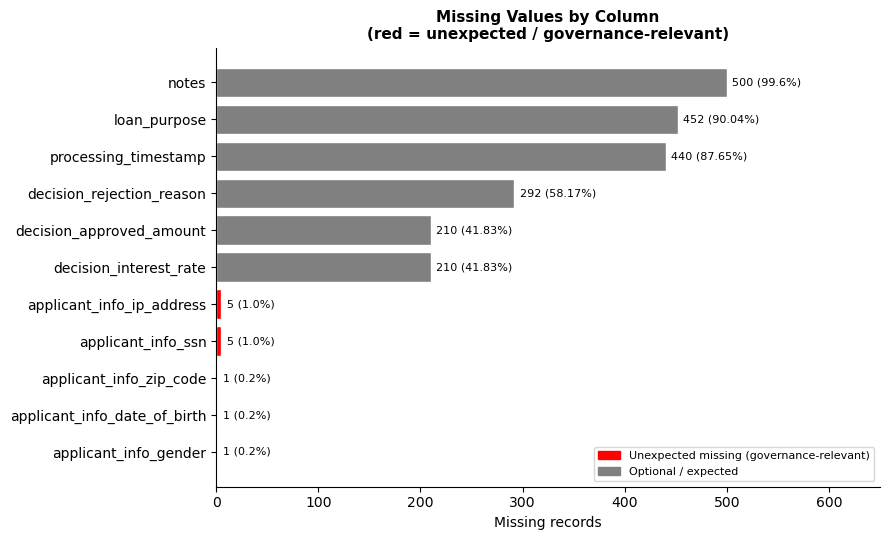

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

mv = completeness_df[completeness_df["missing_count"] > 0].sort_values("missing_count", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(3, len(mv) * 0.5)))

colors = ["red" if not r["expected"] else "grey" for _, r in mv.iterrows()]
bars = ax.barh(mv["column"], mv["missing_count"], color=colors, edgecolor="white")
ax.bar_label(
    bars,
    labels=[f"{int(v)} ({p}%)" for v, p in zip(mv["missing_count"], mv["missing_pct"])],
    padding=4, fontsize=8
)

ax.set_xlabel("Missing records", fontsize=10)
ax.set_title("Missing Values by Column\n(red = unexpected / governance-relevant)", fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, mv["missing_count"].max() * 1.3)
ax.legend(handles=[
    mpatches.Patch(color="red", label="Unexpected missing (governance-relevant)"),
    mpatches.Patch(color="grey", label="Optional / expected"),
], fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

The preceding table and visualization highlight missing values within critical applicant identifiers and demographic attributes, specifically regarding SSN, IP address, gender, date of birth, and ZIP code. Although the absolute counts of missing values are low, these attributes are essential for maintaining rigorous data governance and ensuring the full traceability of individual records. Consequently, these affected records will be flagged and addressed during the remediation phase to preserve the integrity of the curated dataset and ensure that all downstream analyses remain robust and reliable.

### Completeness Check: Email Blank Strings

Beyond identifying null values, we specifically audit the applicant_info_email field for records that contain empty or whitespace-only strings. These instances represent a critical form of incomplete data, as the attribute technically exists within the record but fails to provide a usable value for communication or identity resolution. Identifying these "silent" missing values is essential for ensuring that the final, curated dataset contains only actionable contact information, allowing us to flag and handle these records appropriately during the subsequent remediation phase.

In [18]:
# Completeness: Email blank strings
email_col = "applicant_info_email"
email_raw = df_work[email_col].astype("string").str.strip()

email_blank = df_work[email_col].notna() & (email_raw == "")

count_blank = int(email_blank.sum())
pct_blank = round(count_blank / len(df_work) * 100, 2)

print(f"Blank email strings: {count_blank} ({pct_blank}%)")

if email_blank.any():
    display(df_work.loc[email_blank, ["_id", "applicant_info_full_name", email_col]])

df_work["dq_flag_email_blank_string"] = email_blank

Blank email strings: 7 (1.39%)


,_id,applicant_info_full_name,applicant_info_email
26,app_075,Margaret Williams,
187,app_413,Anthony Jackson,
275,app_120,Carolyn Martin,
297,app_268,Larry Williams,
298,app_377,Anna White,
448,app_350,Linda Adams,
462,app_165,Brandon Moore,


## Consistency

After the completeness check, we look for logical inconsistencies between related fields. In particular, decision attributes (interest rate, approved 
amount, rejection reason) should align with the loan approval outcome. We also review basic consistency in key categorical fields (e.g., gender coding 
and date formats) before remediation.

In [19]:
# Consistency: Decision logic checks

n_rows = len(df_work)

required = [
    "decision_loan_approved",
    "decision_interest_rate",
    "decision_approved_amount",
    "decision_rejection_reason",
]
missing_cols = [c for c in required if c not in df_work.columns]
if missing_cols:
    print("Missing expected decision columns:", missing_cols)

approved = df_work["decision_loan_approved"]

has_rate = df_work["decision_interest_rate"].notna()
has_amount = df_work["decision_approved_amount"].notna()
has_rejection = df_work["decision_rejection_reason"].notna()

# Rules
rej_has_terms = (approved == False) & (has_rate | has_amount)
app_has_rejection = (approved == True) & has_rejection
app_missing_terms = (approved == True) & (~has_rate | ~has_amount)

print(f"Rejected but has interest/amount: {rej_has_terms.sum()}")
print(f"Approved but has rejection reason: {app_has_rejection.sum()}")
print(f"Approved but missing interest/amount: {app_missing_terms.sum()}")

# Store for later remediation section
df_work["dq_flag_decision_rejected_has_terms"] = rej_has_terms
df_work["dq_flag_decision_approved_has_rejection"] = app_has_rejection
df_work["dq_flag_decision_approved_missing_terms"] = app_missing_terms

Rejected but has interest/amount: 0
Approved but has rejection reason: 0
Approved but missing interest/amount: 0


All decision fields are logically consistent with the approval outcome. Rejected applications do not contain loan terms (interest rate / approved amount), approved applications include the required terms, and rejection reasons only appear for rejected cases.

In [20]:
df_work["applicant_info_gender"].value_counts(dropna=False)

applicant_info_gender
Male      195
Female    193
F          58
M          53
            2
NaN         1
Name: count, dtype: int64

Gender values are not consistently coded. The dataset contains both full labels (`Male`, `Female`) and abbreviations (`M`, `F`), as well as a small number of blank/missing entries. We will standardize these to a single representation during remediation.

In [21]:
# Consistency: ZIP code format

zip_col = "applicant_info_zip_code"

zip_raw = df_work[zip_col].astype("string").str.strip()

# Treat empty strings as missing
zip_blank = df_work[zip_col].notna() & (zip_raw == "")

# Only evaluate non-blank present ZIPs
zip_present = df_work[zip_col].notna() & (zip_raw != "")

# Keep digits only (handles spaces, dashes, etc.)
zip_digits = zip_raw.str.replace(r"\D", "", regex=True)
zip_len = zip_digits.str.len()

# Rule: if ZIP is present, it should contain exactly 5 digits
zip_bad = zip_present & (zip_len != 5)

# Placeholder case
zip_placeholder_zero = zip_present & (zip_digits == "0")

print("ZIP blank strings:", int(zip_blank.sum()))
print("ZIP present but not 5 digits:", int(zip_bad.sum()))
print("ZIP placeholder '0' detected:", int(zip_placeholder_zero.sum()))

# Store flags for remediation
df_work["dq_flag_zip_blank_string"] = zip_blank
df_work["dq_flag_zip_bad_format"] = zip_bad
df_work["dq_flag_zip_placeholder_zero"] = zip_placeholder_zero

# Show details only if there are format issues
zip_issue_mask = zip_bad | zip_placeholder_zero
if zip_issue_mask.any():
    zip_issues_preview = df_work.loc[zip_issue_mask, ["_id", zip_col]].copy()
    zip_issues_preview["zip_digits_only"] = zip_digits.loc[zip_issue_mask].values
    zip_issues_preview["zip_digit_len"] = zip_len.loc[zip_issue_mask].values
    display(zip_issues_preview.head(10))
else:
    print("No ZIP format issues to display (only blank-string missingness).")
    
if zip_blank.any():
    print("Example blank ZIP rows:")
    display(df_work.loc[zip_blank, ["_id", zip_col]].head(5))

ZIP blank strings: 1
ZIP present but not 5 digits: 0
ZIP placeholder '0' detected: 0
No ZIP format issues to display (only blank-string missingness).
Example blank ZIP rows:


,_id,applicant_info_zip_code
26,app_075,


ZIP values are correctly formatted when present. One record (`app_075`) uses an empty string instead of a missing value. This will be standardized to `NaN` during remediation.

In [22]:
# Consistency: IP address format

ip_col = "applicant_info_ip_address"

ip_present = df_work[ip_col].notna()
ip_raw = df_work[ip_col].astype("string").str.strip()

# Basic IPv4 pattern: ddd.ddd.ddd.ddd
ip_bad = ip_present & (~ip_raw.str.match(r"^(\d{1,3}\.){3}\d{1,3}$", na=False))

print("IPs present but invalid IPv4 format:", int(ip_bad.sum()))

# Store flag for remediation
df_work["dq_flag_ip_bad_format"] = ip_bad

# Show examples only if any
if ip_bad.any():
    display(df_work.loc[ip_bad, ["_id", ip_col]].head(10))

IPs present but invalid IPv4 format: 0


All present IP addresses follow valid IPv4 format. No consistency issues detected.

In [23]:
# Consistency: SSN format — mask output

ssn_col = "applicant_info_ssn"

ssn_present = df_work[ssn_col].notna()
ssn_raw = df_work[ssn_col].astype("string").str.strip()

ssn_digits = ssn_raw.str.replace(r"\D", "", regex=True)
ssn_bad = ssn_present & (ssn_digits.str.len() != 9)

print("SSNs present but not 9 digits:", int(ssn_bad.sum()))

# Store flag for remediation
df_work["dq_flag_ssn_bad_format"] = ssn_bad

# Show masked examples only if any
if ssn_bad.any():
    tmp = df_work.loc[ssn_bad, ["_id"]].copy()
    tmp["ssn_masked"] = "***-**-" + ssn_digits.loc[ssn_bad].str[-4:]
    display(tmp.head(10))

SSNs present but not 9 digits: 0


SSNs are consistently formatted (all present values normalize to 9 digits).

We assess format consistency in `date_of_birth` by identifying whether values follow a single standardized representation (ISO `YYYY-MM-DD`) or appear in mixed formats. This check is important because inconsistent date formats can affect downstream parsing, age calculations, and duplicate detection.

In [24]:
# Consistency - Date format consistency

import re

dob_col = "applicant_info_date_of_birth"
n_rows = len(df_work)

def pct(x, total=n_rows):
    return round((x / total) * 100, 2) if total else 0.0

dob_raw = df_work[dob_col].astype("string")
dob_stripped = dob_raw.str.strip()

# Separate completeness-related cases from format consistency
dob_missing_mask = df_work[dob_col].isna()
dob_blank_mask = df_work[dob_col].notna() & (dob_stripped == "")

def detect_dob_format(v):
    if pd.isna(v):
        return "missing"
    s = str(v).strip()
    if s == "":
        return "blank"
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", s):
        return "YYYY-MM-DD (ISO)"
    if re.fullmatch(r"\d{4}/\d{2}/\d{2}", s):
        return "YYYY/MM/DD"
    if re.fullmatch(r"\d{2}/\d{2}/\d{4}", s):
        return "DD/MM/YYYY or MM/DD/YYYY"
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", s):
        return "DD-MM-YYYY or MM-DD-YYYY"
    return "other/unrecognized"

df_work["analysis_dob_format"] = df_work[dob_col].apply(detect_dob_format)

dob_format_dist = (
    df_work["analysis_dob_format"]
    .value_counts(dropna=False)
    .rename_axis("dob_format_category")
    .reset_index(name="count")
)
dob_format_dist["pct"] = (dob_format_dist["count"] / n_rows * 100).round(2)

display(dob_format_dist)

,dob_format_category,count,pct
0,YYYY-MM-DD (ISO),340,67.73
1,DD/MM/YYYY or MM/DD/YYYY,101,20.12
2,YYYY/MM/DD,56,11.16
3,blank,4,0.80
4,missing,1,0.20


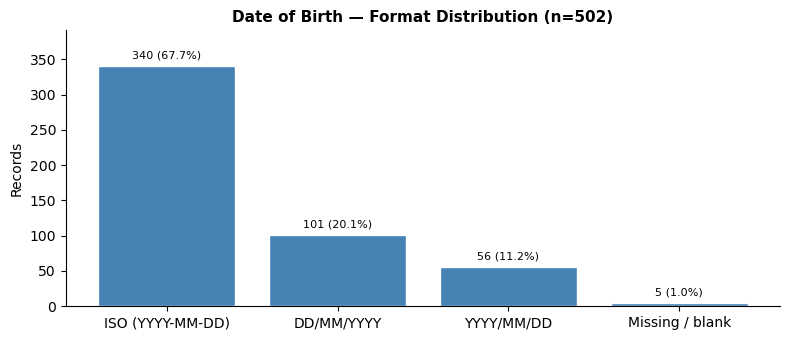

In [25]:
import matplotlib.pyplot as plt
import re

dob_series = df_work["applicant_info_date_of_birth"].astype(str)

n_iso      = dob_series.apply(lambda x: bool(re.match(r'^\d{4}-\d{2}-\d{2}$', x))).sum()
n_ddmmyyyy = dob_series.apply(lambda x: bool(re.match(r'^\d{2}/\d{2}/\d{4}$', x))).sum()
n_yyyymmdd = dob_series.apply(lambda x: bool(re.match(r'^\d{4}/\d{2}/\d{2}$', x))).sum()
n_missing  = df_work["applicant_info_date_of_birth"].isna().sum()
n_blank    = (dob_series == "").sum()

dob_format_counts = {
    "ISO (YYYY-MM-DD)": n_iso,
    "DD/MM/YYYY":       n_ddmmyyyy,
    "YYYY/MM/DD":       n_yyyymmdd,
    "Missing / blank":  n_missing + n_blank,
}

# Sort by value descending
dob_format_counts = dict(sorted(dob_format_counts.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(8, 3.5))

bars = ax.bar(dob_format_counts.keys(), dob_format_counts.values(), color="steelblue", edgecolor="white")
ax.bar_label(bars, labels=[f"{v} ({v/len(df_work)*100:.1f}%)" for v in dob_format_counts.values()], padding=4, fontsize=8)

ax.set_ylabel("Records", fontsize=10)
ax.set_title("Date of Birth — Format Distribution (n=502)", fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(dob_format_counts.values()) * 1.15)

plt.tight_layout()
plt.show()

In [26]:
# Create  helper column for downstream analysis (e.g., age validity checks)

from datetime import datetime

def parse_dob_multi(v):
    if pd.isna(v):
        return pd.NaT
    s = str(v).strip()
    if s == "":
        return pd.NaT
    
    for fmt in ("%Y-%m-%d", "%Y/%m/%d", "%d/%m/%Y", "%d-%m-%Y", "%m/%d/%Y", "%m-%d-%Y"):
        try:
            return pd.Timestamp(datetime.strptime(s, fmt))
        except ValueError:
            continue
    return pd.NaT

df_work["analysis_dob_parsed"] = df_work[dob_col].apply(parse_dob_multi)

# Flags for later reporting/remediation
dob_unparseable_mask = (
    ~dob_missing_mask
    & ~dob_blank_mask
    & df_work["analysis_dob_parsed"].isna()
)

dob_non_iso_valid_mask = (
    ~dob_missing_mask
    & ~dob_blank_mask
    & (df_work["analysis_dob_format"] != "YYYY-MM-DD (ISO)")
    & (~df_work["analysis_dob_parsed"].isna())
)

df_work["dq_flag_dob_blank_string"] = dob_blank_mask
df_work["dq_flag_dob_non_iso_format"] = dob_non_iso_valid_mask
df_work["dq_flag_dob_unparseable"] = dob_unparseable_mask

print(f"DOB missing values: {int(dob_missing_mask.sum())} ({pct(int(dob_missing_mask.sum()))}%)")
print(f"DOB blank strings: {int(dob_blank_mask.sum())} ({pct(int(dob_blank_mask.sum()))}%)")
print(f"DOB valid non-ISO formats: {int(dob_non_iso_valid_mask.sum())} ({pct(int(dob_non_iso_valid_mask.sum()))}%)")
print(f"DOB unparseable values: {int(dob_unparseable_mask.sum())} ({pct(int(dob_unparseable_mask.sum()))}%)")

if dob_unparseable_mask.any():
    display(
        df_work.loc[dob_unparseable_mask, ["_id", "applicant_info_full_name", dob_col]]
        .head(10)
    )

DOB missing values: 1 (0.2%)
DOB blank strings: 4 (0.8%)
DOB valid non-ISO formats: 157 (31.27%)
DOB unparseable values: 0 (0.0%)


In [27]:
# Data quality summary by dimension (count + percentage)
dob_consistency_summary = pd.DataFrame([
    {
        "issue": "DOB missing values",
        "dq_dimension": "Completeness",
        "affected_rows": int(dob_missing_mask.sum())
    },
    {
        "issue": "DOB blank strings",
        "dq_dimension": "Completeness",
        "affected_rows": int(df_work["dq_flag_dob_blank_string"].sum())
    },
    {
        "issue": "DOB valid non-ISO formats",
        "dq_dimension": "Consistency",
        "affected_rows": int(df_work["dq_flag_dob_non_iso_format"].sum())
    },
    {
        "issue": "DOB unparseable values",
        "dq_dimension": "Validity",
        "affected_rows": int(df_work["dq_flag_dob_unparseable"].sum())
    },
])

dob_consistency_summary["affected_pct"] = (dob_consistency_summary["affected_rows"] / n_rows * 100).round(2)
dob_consistency_summary = dob_consistency_summary.sort_values("affected_rows", ascending=False).reset_index(drop=True)
display(dob_consistency_summary)

,issue,dq_dimension,affected_rows,affected_pct
0,DOB valid non-ISO formats,Consistency,157,31.27
1,DOB blank strings,Completeness,4,0.80
2,DOB missing values,Completeness,1,0.20
3,DOB unparseable values,Validity,0,0.00


The `date_of_birth` assessment shows that the main issue is format inconsistency rather than invalid date values. While a small number of records contain missing or blank DOB entries (completeness issues), a substantial share of records (**31.27%**) store valid DOB values in non-standard (non-ISO) formats (consistency issue). No unparseable DOB values were identified in this dataset. This supports a remediation strategy focused primarily on date standardization rather than record exclusion.

## Uniqueness

We next assess **uniqueness** by checking whether records that should be unique are repeated in the dataset.

The main checks focus on:
- duplicate application identifiers (`_id`)
- duplicate SSNs (excluding missing values)
- duplicate combinations of applicant name and date of birth (possible repeated applications or duplicate records)

This section only performs detection and quantification. Any deduplication decisions are deferred to the Remediation section to avoid changing the dataset during the assessment stage.

In [28]:
# Uniqueness - duplicate detection

n_rows = len(df_work)

def pct(x, total=n_rows):
    return round((x / total) * 100, 2) if total else 0.0

# Duplicate application IDs (_id)
id_series = df_work["_id"].astype("string").str.strip()
id_present_mask = id_series.notna() & (id_series != "")
dup_id_mask = id_present_mask & id_series.duplicated(keep=False)

print(f"Rows with duplicate _id: {int(dup_id_mask.sum())} ({pct(int(dup_id_mask.sum()))}%)")

if dup_id_mask.any():
    display(
        df_work.loc[dup_id_mask, ["_id", "applicant_info_full_name", "applicant_info_date_of_birth"]]
        .sort_values("_id")
    )

# Save flag for later remediation
df_work["dq_flag_duplicate_id"] = dup_id_mask

Rows with duplicate _id: 4 (0.8%)


,_id,applicant_info_full_name,applicant_info_date_of_birth
383,app_001,Stephanie Nguyen,1986-05-27
455,app_001,Stephanie Nguyen,NaN
8,app_042,Joseph Lopez,1990-05-04
354,app_042,Joseph Lopez,1990-05-04


In [29]:
# Duplicate SSNs (exclude missing/blank values)
ssn_col = "applicant_info_ssn"

ssn_series = df_work[ssn_col].astype("string").str.strip()
ssn_present_mask = ssn_series.notna() & (ssn_series != "")

# Normalize SSN for matching (remove separators)
ssn_norm = ssn_series.str.replace(r"\D", "", regex=True)

# Only treat 9-digit SSNs as valid duplicate keys
ssn_valid_mask = ssn_present_mask & (ssn_norm.str.len() == 9)

dup_ssn_mask = ssn_valid_mask & ssn_norm.duplicated(keep=False)

print(f"Rows with duplicate valid SSN: {int(dup_ssn_mask.sum())} ({pct(int(dup_ssn_mask.sum()))}%)")

if dup_ssn_mask.any():
    ssn_preview = df_work.loc[
        dup_ssn_mask,
        ["_id", "applicant_info_full_name", "applicant_info_date_of_birth"]
    ].copy()
    ssn_preview["ssn_masked"] = "***-**-" + ssn_norm.loc[dup_ssn_mask].str[-4:].values
    display(ssn_preview.sort_values(["ssn_masked", "_id"]))

# Save flag for later remediation
df_work["dq_flag_duplicate_ssn"] = dup_ssn_mask

Rows with duplicate valid SSN: 6 (1.2%)


,_id,applicant_info_full_name,applicant_info_date_of_birth,ssn_masked
8,app_042,Joseph Lopez,1990-05-04,***-**-5530
354,app_042,Joseph Lopez,1990-05-04,***-**-5530
16,app_101,Sandra Smith,1997-03-23,***-**-8731
499,app_234,Samuel Hill,1976/01/29,***-**-8731
122,app_016,Gary Wilson,1959-12-11,***-**-9300
92,app_088,Susan Martinez,1986-10-15,***-**-9300


In [30]:
# Duplicate Full Name + DOB
name_series = df_work["applicant_info_full_name"].astype("string").str.strip().str.lower()
dob_series = df_work["applicant_info_date_of_birth"].astype("string").str.strip()

name_present_mask = name_series.notna() & (name_series != "")
dob_present_mask = dob_series.notna() & (dob_series != "")
key_present_mask = name_present_mask & dob_present_mask

name_dob_key = pd.Series(list(zip(name_series, dob_series)), index=df_work.index)
dup_name_dob_mask = key_present_mask & name_dob_key.duplicated(keep=False)

print(f"Rows with duplicate Full Name + DOB (raw string): {int(dup_name_dob_mask.sum())} ({pct(int(dup_name_dob_mask.sum()))}%)")

if dup_name_dob_mask.any():
    name_dob_preview = df_work.loc[
        dup_name_dob_mask,
        ["_id", "applicant_info_full_name", "applicant_info_date_of_birth", "applicant_info_ssn"]
    ].copy()

    # Mask SSN for display (keep only last 4 digits)
    ssn_preview_raw = name_dob_preview["applicant_info_ssn"].astype("string").str.strip()
    ssn_preview_digits = ssn_preview_raw.str.replace(r"\D", "", regex=True)

    name_dob_preview["applicant_info_ssn_masked"] = np.where(
        ssn_preview_digits.str.len() == 9,
        "***-**-" + ssn_preview_digits.str[-4:],
        pd.NA
    )

    # Drop raw SSN from the preview to avoid exposing PII
    name_dob_preview = name_dob_preview.drop(columns=["applicant_info_ssn"])

    display(
        name_dob_preview.sort_values(
            ["applicant_info_full_name", "applicant_info_date_of_birth"]
        )
    )

# Save flag for later remediation
df_work["dq_flag_duplicate_name_dob"] = dup_name_dob_mask

Rows with duplicate Full Name + DOB (raw string): 2 (0.4%)


,_id,applicant_info_full_name,applicant_info_date_of_birth,applicant_info_ssn_masked
8,app_042,Joseph Lopez,1990-05-04,***-**-5530
354,app_042,Joseph Lopez,1990-05-04,***-**-5530


In [31]:
# Uniqueness summary (count + percentage)
uniqueness_summary = pd.DataFrame([
    {
        "issue": "Duplicate application ID (_id)",
        "dq_dimension": "Uniqueness",
        "affected_rows": int(df_work["dq_flag_duplicate_id"].sum())
    },
    {
        "issue": "Duplicate valid SSN",
        "dq_dimension": "Uniqueness",
        "affected_rows": int(df_work["dq_flag_duplicate_ssn"].sum())
    },
    {
        "issue": "Duplicate Full Name + DOB (raw DOB string)",
        "dq_dimension": "Uniqueness",
        "affected_rows": int(df_work["dq_flag_duplicate_name_dob"].sum())
    }
])

uniqueness_summary = uniqueness_summary.sort_values("affected_rows", ascending=False).reset_index(drop=True)
display(uniqueness_summary)

,issue,dq_dimension,affected_rows
0,Duplicate valid SSN,Uniqueness,6
1,Duplicate application ID (_id),Uniqueness,4
2,Duplicate Full Name + DOB (raw DOB string),Uniqueness,2


In [32]:
# Distinct records flagged by at least one uniqueness rule (union of checks)
uniqueness_any_flag_mask = (
    df_work["dq_flag_duplicate_id"]
    | df_work["dq_flag_duplicate_ssn"]
    | df_work["dq_flag_duplicate_name_dob"]
)

n_uniqueness_flagged_distinct = int(uniqueness_any_flag_mask.sum())
pct_uniqueness_flagged_distinct = round(n_uniqueness_flagged_distinct / len(df_work) * 100, 2)

print(
    f"Distinct records flagged by at least one uniqueness check: "
    f"{n_uniqueness_flagged_distinct} ({pct_uniqueness_flagged_distinct}%)"
)

# Preview
display(
    df_work.loc[
        uniqueness_any_flag_mask,
        ["_id", "applicant_info_full_name", "applicant_info_date_of_birth"]
    ].sort_values(["_id", "applicant_info_full_name"]).head(20)
)

Distinct records flagged by at least one uniqueness check: 8 (1.59%)


,_id,applicant_info_full_name,applicant_info_date_of_birth
383,app_001,Stephanie Nguyen,1986-05-27
455,app_001,Stephanie Nguyen,NaN
122,app_016,Gary Wilson,1959-12-11
8,app_042,Joseph Lopez,1990-05-04
354,app_042,Joseph Lopez,1990-05-04
92,app_088,Susan Martinez,1986-10-15
16,app_101,Sandra Smith,1997-03-23
499,app_234,Samuel Hill,1976/01/29


The uniqueness assessment identifies both record-level and applicant-level duplication signals in the dataset. Specifically, duplicated application identifiers (`_id`) are observed in **4 records (0.8%)**, duplicated valid SSNs in **6 records (1.2%)**, and duplicated `Full Name + Date of Birth` combinations in **2 records (0.4%)**.

These checks are complementary and overlap in some cases. Therefore, the counts reported by rule are not additive. When combined, a total of **8 distinct records (1.59%)** are flagged by at least one uniqueness rule. Deduplication decisions are deferred to the Remediation section, where stronger identifiers (e.g., `_id`, valid SSN) will be prioritized and flagged cases will be reviewed for traceability.

## Validity

We evaluate **validity** issues by identifying values that are implausible, out of range, 
or logically impossible given the context of credit applications.

This section focuses on:
- **Numeric plausibility** — negative values in fields that should be non-negative (e.g., credit history length, savings balance, annual income) and debt-to-income ratios above expected bounds
- **Age plausibility** — impossible ages derived from `date_of_birth` (e.g., implausibly young or old applicants)
- **Structural validity** — verifying that `applicant_info_email` follows a basic valid email structure format

At this stage, we only detect and quantify validity issues. Remediation decisions are 
deferred to the Remediation section.

In [33]:
# Validity - numeric plausibility checks


# Analysis-only numeric conversions
analysis_chm = pd.to_numeric(df_work["financials_credit_history_months"], errors="coerce")
analysis_income = pd.to_numeric(df_work["financials_annual_income_canonical"], errors="coerce")
analysis_savings = pd.to_numeric(df_work["financials_savings_balance"], errors="coerce")
analysis_dti = pd.to_numeric(df_work["financials_debt_to_income"], errors="coerce")

In [34]:
neg_chm_mask = analysis_chm < 0

print(f"Negative credit_history_months: {int(neg_chm_mask.sum())} ({pct(int(neg_chm_mask.sum()))}%)")

if neg_chm_mask.any():
    display(
        df_work.loc[
            neg_chm_mask,
            ["_id", "applicant_info_full_name", "financials_credit_history_months"]
        ]
    )

df_work["dq_flag_neg_credit_history_months"] = neg_chm_mask

Negative credit_history_months: 2 (0.4%)


,_id,applicant_info_full_name,financials_credit_history_months
137,app_043,Daniel King,-10
162,app_156,Jessica Green,-3


In [35]:
neg_income_mask = analysis_income < 0

print(f"Negative annual_income (canonical): {int(neg_income_mask.sum())} ({pct(int(neg_income_mask.sum()))}%)")

if neg_income_mask.any():
    display(
        df_work.loc[
            neg_income_mask,
            ["_id", "applicant_info_full_name", "financials_annual_income_canonical"]
        ]
    )

df_work["dq_flag_neg_annual_income"] = neg_income_mask

Negative annual_income (canonical): 0 (0.0%)


In [36]:
neg_savings_mask = analysis_savings < 0

print(f"Negative savings_balance: {int(neg_savings_mask.sum())} ({pct(int(neg_savings_mask.sum()))}%)")

if neg_savings_mask.any():
    display(
        df_work.loc[
            neg_savings_mask,
            ["_id", "applicant_info_full_name", "financials_savings_balance"]
        ]
    )

df_work["dq_flag_neg_savings_balance"] = neg_savings_mask

Negative savings_balance: 1 (0.2%)


,_id,applicant_info_full_name,financials_savings_balance
159,app_290,Stephanie Perez,-5000


In [37]:
dti_over_1_mask = analysis_dti > 1.0

print(f"Debt-to-income ratio > 1.0: {int(dti_over_1_mask.sum())} ({pct(int(dti_over_1_mask.sum()))}%)")

if dti_over_1_mask.any():
    display(
        df_work.loc[
            dti_over_1_mask,
            ["_id", "applicant_info_full_name", "financials_debt_to_income"]
        ]
    )

df_work["dq_flag_dti_over_1"] = dti_over_1_mask

Debt-to-income ratio > 1.0: 1 (0.2%)


,_id,applicant_info_full_name,financials_debt_to_income
316,app_402,Heather Flores,1.85


In [38]:
# Validity - age plausibility check

if "analysis_dob_parsed" not in df_work.columns:
    raise ValueError("analysis_dob_parsed not found. Run the DOB consistency parsing cell before the age validity check.")

today = pd.Timestamp.today().normalize()
df_work["analysis_age_years"] = ((today - df_work["analysis_dob_parsed"]).dt.days / 365.25)

impossible_age_mask = (
    df_work["analysis_age_years"].notna() &
    (
        (df_work["analysis_age_years"] < 18) |
        (df_work["analysis_age_years"] > 120)
    )
)

print(f"Impossible ages (<18 or >120): {int(impossible_age_mask.sum())} ({pct(int(impossible_age_mask.sum()))}%)")

if impossible_age_mask.any():
    age_preview = df_work.loc[
        impossible_age_mask,
        ["_id", "applicant_info_full_name", "applicant_info_date_of_birth", "analysis_dob_parsed", "analysis_age_years"]
    ].copy()
    age_preview["analysis_age_years"] = age_preview["analysis_age_years"].round(1)
    display(age_preview)

df_work["dq_flag_impossible_age"] = impossible_age_mask

Impossible ages (<18 or >120): 0 (0.0%)


In [39]:
# Validity: Email format

email_col = "applicant_info_email"
email_raw = df_work[email_col].astype("string").str.strip()

email_pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"

email_invalid = (
    df_work[email_col].notna()
    & (email_raw != "")
    & ~email_raw.str.match(email_pattern, na=False)
)

print(f"Invalid email format: {int(email_invalid.sum())} ({pct(int(email_invalid.sum()))}%)")

if email_invalid.any():
    display(df_work.loc[email_invalid, ["_id", "applicant_info_full_name", email_col]])

df_work["dq_flag_email_invalid_format"] = email_invalid

Invalid email format: 4 (0.8%)


,_id,applicant_info_full_name,applicant_info_email
138,app_204,Jonathan Carter,mike johnson@gmail.com
181,app_299,Samuel Gonzalez,test.user.outlook.com
276,app_068,Emily Lopez,john.doe@invalid
369,app_146,Amy Flores,sarah.smith@


In [40]:
# Validity summary by rule (count + percentage)

validity_summary = pd.DataFrame([
    {
        "issue": "Negative credit_history_months",
        "dq_dimension": "Validity",
        "affected_rows": int(df_work["dq_flag_neg_credit_history_months"].sum())
    },
    {
        "issue": "Negative annual_income (canonical)",
        "dq_dimension": "Validity",
        "affected_rows": int(df_work["dq_flag_neg_annual_income"].sum())
    },
    {
        "issue": "Negative savings_balance",
        "dq_dimension": "Validity",
        "affected_rows": int(df_work["dq_flag_neg_savings_balance"].sum())
    },
    {
        "issue": "Debt-to-income ratio > 1.0",
        "dq_dimension": "Validity",
        "affected_rows": int(df_work["dq_flag_dti_over_1"].sum())
    },
    {
        "issue": "Impossible age (<18 or >120)",
        "dq_dimension": "Validity",
        "affected_rows": int(df_work["dq_flag_impossible_age"].sum())
    },
    {
        "issue": "Invalid email format",
        "dq_dimension": "Validity",
        "affected_rows": int(df_work["dq_flag_email_invalid_format"].sum())
    },

])

validity_summary = validity_summary.sort_values("affected_rows", ascending=False).reset_index(drop=True)
display(validity_summary)

,issue,dq_dimension,affected_rows
0,Invalid email format,Validity,4
1,Negative credit_history_months,Validity,2
2,Negative savings_balance,Validity,1
3,Debt-to-income ratio > 1.0,Validity,1
4,Negative annual_income (canonical),Validity,0
5,Impossible age (<18 or >120),Validity,0


In [41]:
# Distinct records flagged by at least one validity rule
validity_any_flag_mask = (
    df_work["dq_flag_neg_credit_history_months"]
    | df_work["dq_flag_neg_annual_income"]
    | df_work["dq_flag_neg_savings_balance"]
    | df_work["dq_flag_dti_over_1"]
    | df_work["dq_flag_impossible_age"]
    | df_work["dq_flag_email_invalid_format"]
)

n_validity_flagged_distinct = int(validity_any_flag_mask.sum())
pct_validity_flagged_distinct = round(n_validity_flagged_distinct / len(df_work) * 100, 2)

print(
    f"Distinct records flagged by at least one validity check: "
    f"{n_validity_flagged_distinct} ({pct_validity_flagged_distinct}%)"
)

display(
    df_work.loc[
        validity_any_flag_mask,
        [
            "_id",
            "applicant_info_full_name",
            "applicant_info_email",
            "applicant_info_date_of_birth",
            "financials_credit_history_months",
            "financials_annual_income_canonical",
            "financials_savings_balance",
            "financials_debt_to_income"
        ]
    ]
)

Distinct records flagged by at least one validity check: 8 (1.59%)


,_id,applicant_info_full_name,applicant_info_email,applicant_info_date_of_birth,financials_credit_history_months,financials_annual_income_canonical,financials_savings_balance,financials_debt_to_income
137,app_043,Daniel King,daniel.king27@mail.com,1985-08-17,-10,131000,53098,0.06
138,app_204,Jonathan Carter,mike johnson@gmail.com,1983-04-12,63,81000,14018,0.22
159,app_290,Stephanie Perez,stephanie.perez69@gmail.com,1990-01-06,39,104000,-5000,0.27
162,app_156,Jessica Green,jessica.green86@gmail.com,1999-11-28,-3,25000,13641,0.21
181,app_299,Samuel Gonzalez,test.user.outlook.com,1972-08-28,58,64000,23101,0.18
276,app_068,Emily Lopez,john.doe@invalid,1993-09-05,30,75000,40791,0.31
316,app_402,Heather Flores,heather.flores23@mail.com,1965-03-07,27,88000,37281,1.85
369,app_146,Amy Flores,sarah.smith@,1970-04-26,102,79000,24961,0.20


The validity assessment identifies a limited number of implausible or improperly formatted values in the dataset. Specifically, **2 records (0.4%)** contain negative `credit_history_months`, **1 record (0.2%)** contains a negative `savings_balance`, and **1 record (0.2%)** has a `debt_to_income` ratio above 1.0. No negative values were identified in the canonical annual income field, and no implausible ages (<18 or >120) were detected based on parsed DOB values. Additionally, **4 records (0.8%)** contain an invalid email format in `applicant_info_email`.

Although validity issues are relatively infrequent, they affect financially relevant variables and may distort downstream risk analysis if left untreated. In total, **8 distinct records (1.6%)** are flagged by at least one validity rule. Remediation decisions are deferred to the Remediation section.

## Accuracy

We evaluate **accuracy** by checking whether plausible values are nevertheless incorrect given their real-world context.
Unlike validity, which flags impossible value, accuracy addresses subtler issues where values are within range but internally inconsistent or contextually implausible.

The checks focus on:
- **Decision field cross-referencing**: approved records should carry `interest_rate` and `approved_amount`, rejected records should carry `rejection_reason` and no loan terms
- **Age vs credit history coherence** — `credit_history_months` should not exceed the number of months the applicant has been of legal age (18 years)

At this stage, we only detect and quantify accuracy issues. Any remediation decisions are deferred to the Remediation section.

In [42]:
today = pd.Timestamp.today().normalize()

dob_series = df_work["applicant_info_date_of_birth"].copy()

dob_parsed = pd.to_datetime(dob_series, errors="coerce", format="%Y-%m-%d")
mask_missing = dob_parsed.isna() & dob_series.notna()
dob_alt = pd.to_datetime(dob_series.loc[mask_missing], errors="coerce", dayfirst=True)
dob_parsed.update(dob_alt)

age_years = ((today - dob_parsed).dt.days / 365.25).round(1)
chm = pd.to_numeric(df_work["financials_credit_history_months"], errors="coerce")

total_approved = (df_work["decision_loan_approved"] == True).sum()
total_rejected = (df_work["decision_loan_approved"] == False).sum()
total_records = len(df_work)

check1 = ((df_work["decision_loan_approved"] == True) &
          df_work["decision_interest_rate"].notna() &
          df_work["decision_approved_amount"].notna()).sum()

check2 = ((df_work["decision_loan_approved"] == False) &
          df_work["decision_rejection_reason"].notna() &
          df_work["decision_interest_rate"].isna()).sum()

max_possible_chm = (age_years - 18) * 12
age_chm_incoherent = (age_years.notna() & chm.notna() & (chm > max_possible_chm))
check3_fail = age_chm_incoherent.sum()

acc_summary = pd.DataFrame({
    "check": [
        "Approved loans with interest_rate and approved_amount",
        "Rejected loans with rejection_reason and no loan terms",
        "Age vs credit history coherence"
    ],
    "pass_count": [check1, check2, total_records - check3_fail],
    "total": [total_approved, total_rejected, total_records]
})

acc_summary["pass_pct"] = (acc_summary["pass_count"] / acc_summary["total"] * 100).round(2)
acc_summary["fail_count"] = acc_summary["total"] - acc_summary["pass_count"]
acc_summary = acc_summary.sort_values("fail_count", ascending=False).reset_index(drop=True)

display(acc_summary)

if age_chm_incoherent.any():
    print(f"\nRecords where credit history exceeds age-based maximum ({check3_fail} records):")
    display(df_work.loc[age_chm_incoherent, [
        "_id", "applicant_info_full_name",
        "applicant_info_date_of_birth",
        "financials_credit_history_months"
    ]].assign(age_years=age_years, max_possible_chm=max_possible_chm.round(0)))
else:
    print("No age vs credit history coherence issues detected.")

df_work["dq_flag_age_chm_incoherent"] = age_chm_incoherent

,check,pass_count,total,pass_pct,fail_count
0,Approved loans with interest_rate and approved...,292,292,100.0,0
1,Rejected loans with rejection_reason and no lo...,210,210,100.0,0
2,Age vs credit history coherence,502,502,100.0,0


No age vs credit history coherence issues detected.


### Structural Prep: Unpacking Nested Spending Data
The `spending_behavior` column contains nested lists of transaction dictionaries. We must extract this into a separate flattened dataframe (`spending_df`) so we can evaluate transaction-level data quality (such as completeness, consistency, and validity) in the upcoming sections.

In [43]:
# Pre check: records with no spending data at all
missing_spending = df_work['spending_behavior'].isna().sum()
print(f"Completeness - Records with no spending data: {missing_spending} ({missing_spending/len(df_work)*100:.2f}%)")

# Unpacking
spending_exploded = df_work[['_id', 'spending_behavior']].explode('spending_behavior').dropna(subset=['spending_behavior'])
spending_df = pd.json_normalize(spending_exploded['spending_behavior'])
spending_df['_id'] = spending_exploded['_id'].values
print(f"Total transactions unpacked: {len(spending_df)}\n")

# Completeness
missing_categories = spending_df['category'].isna().sum()
missing_amounts = spending_df['amount'].isna().sum()
print(f"Completeness - Missing categories: {missing_categories} ({missing_categories/len(spending_df)*100:.2f}%)")
print(f"Completeness - Missing amounts: {missing_amounts} ({missing_amounts/len(spending_df)*100:.2f}%)\n")

# Consistency
print("Consistency - Unique Spending Categories:")
print(spending_df['category'].value_counts(dropna=False))
print()

# Validity
# Check for strings hiding in the amount column
string_amounts = spending_df['amount'].apply(lambda x: isinstance(x, str))
print(f"Validity - Amounts stored as strings: {string_amounts.sum()} ({string_amounts.sum()/len(spending_df)*100:.2f}%)")

# Check for negative amounts
numeric_amounts = pd.to_numeric(spending_df['amount'], errors='coerce')
negative_amounts = (numeric_amounts < 0)
print(f"Validity - Negative transaction amounts: {negative_amounts.sum()} ({negative_amounts.sum()/len(spending_df)*100:.2f}%)")

# Flag
# Tag individual transactions
spending_df["dq_flag_string_amount"] = string_amounts
spending_df["dq_flag_negative_amount"] = negative_amounts

# Connect bad spending records back to main dataframe
ids_with_bad_spending = spending_df.loc[string_amounts | negative_amounts, '_id'].unique()
df_work['dq_flag_invalid_spending'] = df_work['_id'].isin(ids_with_bad_spending)
print(f"\nRecords in df_work flagged for invalid spending data: {df_work['dq_flag_invalid_spending'].sum()}")

Completeness - Records with no spending data: 0 (0.00%)
Total transactions unpacked: 827

Completeness - Missing categories: 0 (0.00%)
Completeness - Missing amounts: 0 (0.00%)

Consistency - Unique Spending Categories:
category
Travel                 80
Utilities              76
Entertainment          72
Fitness                71
Healthcare             68
Insurance              68
Dining                 66
Groceries              65
Education              64
Transportation         61
Rent                   59
Shopping               54
Alcohol                11
Gambling                7
Adult Entertainment     5
Name: count, dtype: int64

Validity - Amounts stored as strings: 0 (0.00%)
Validity - Negative transaction amounts: 0 (0.00%)

Records in df_work flagged for invalid spending data: 0


## 02 - Data Remediation
After identifying and quantifying the data quality issues in the preceding sections, we apply targeted remediation to each category. Our strategy is documented in the table below:

| Issue | Strategy |
|---|---|
| Duplicate `_id` records | Remove exact duplicates (keep first occurrence) |
| Inconsistent gender coding | Map all variants to `Male`, `Female`, or `Unknown` |
| Inconsistent date-of-birth formats | Parse to ISO 8601 (`YYYY-MM-DD`) |
| Annual income stored as string | Cast to numeric (float); unparseable values → `NaN` |
| Negative `credit_history_months` | Set to `NaN` (impossible by definition) |
| Debt-to-income ratio > 1.0 | Set to `NaN` (impossible by definition) |
| Negative `savings_balance` | Set to `NaN` (anomalous; overdraft logic not in scope) |
| Empty-string ZIP code | Replace with `NaN` |
| Empty-string email | Replace with `NaN` |
| Invalid email format | Set to `NaN` (invalid contact information) |

All changes are applied to a fresh copy (`df_clean`) while `df_work` is preserved unchanged for auditability and validation.

In [44]:
# Create clean copy — df_work preserved unchanged for audit
df_clean = df_work.copy()
n_raw = len(df_clean)
print(f"Starting records: {n_raw}")

Starting records: 502


### Uniqueness: Duplicate SSN Across Different Applicants

Potential duplicate SSNs are evaluated using a canonical SSN representation (digits only) to avoid false negatives caused by formatting differences. Duplicate detection is performed only on valid 9-digit SSN values.

Because duplicate SSNs across different applicants may indicate fraud, identity reuse, or upstream data integration errors, affected records are **flagged for manual review** rather than automatically removed.

In [45]:
# Show duplicates before removal
dup_mask = df_clean.duplicated(subset="_id", keep=False)
n_dup_id_rows = int(dup_mask.sum())
print(f"Rows involved in _id duplication before removal: {n_dup_id_rows}")
display(df_clean.loc[dup_mask, ["_id", "applicant_info_full_name"]].sort_values("_id"))

# Remove duplicate _id records — keep first occurrence
df_clean = df_clean.drop_duplicates(subset="_id", keep="first").reset_index(drop=True)
n_after_dedup = len(df_clean)
n_id_records_removed = int(n_raw - n_after_dedup)
print(f"\nRecords removed: {n_id_records_removed}")
print(f"Records remaining: {n_after_dedup}")

# Duplicate SSNs — flag for review, do not remove (using canonical SSN logic)
ssn_col = "applicant_info_ssn"

# Canonicalize to digits only (matches assessment logic)
ssn_raw = df_clean[ssn_col].astype("string").str.strip()
ssn_digits = ssn_raw.str.replace(r"\D", "", regex=True)

# Only valid 9-digit SSNs participate in duplicate detection
ssn_canonical = ssn_digits.where(ssn_digits.str.fullmatch(r"\d{9}"), pd.NA)

# Store canonical version for auditability/debugging
df_clean["applicant_info_ssn_canonical"] = ssn_canonical

dup_ssn_mask = ssn_canonical.notna() & ssn_canonical.duplicated(keep=False)
df_clean["dq_flag_dup_ssn"] = dup_ssn_mask.fillna(False)

print(
    f"\nRecords sharing a valid canonical SSN with another record: "
    f"{int(df_clean['dq_flag_dup_ssn'].sum())} (flagged, not removed)"
)

# Preview flagged SSN duplicates
if df_clean["dq_flag_dup_ssn"].sum() > 0:
    print("\nRecords flagged for duplicate SSN:")
    display(
        df_clean.loc[
            df_clean["dq_flag_dup_ssn"],
            ["_id", "applicant_info_full_name", "applicant_info_date_of_birth", ssn_col, "applicant_info_ssn_canonical"]
        ].sort_values(["applicant_info_ssn_canonical", "_id"])
    )

Rows involved in _id duplication before removal: 4


,_id,applicant_info_full_name
383,app_001,Stephanie Nguyen
455,app_001,Stephanie Nguyen
8,app_042,Joseph Lopez
354,app_042,Joseph Lopez



Records removed: 2
Records remaining: 500

Records sharing a valid canonical SSN with another record: 4 (flagged, not removed)

Records flagged for duplicate SSN:


,_id,applicant_info_full_name,applicant_info_date_of_birth,applicant_info_ssn,applicant_info_ssn_canonical
122,app_016,Gary Wilson,1959-12-11,780-24-9300,780249300
92,app_088,Susan Martinez,1986-10-15,780-24-9300,780249300
16,app_101,Sandra Smith,1997-03-23,937-72-8731,937728731
497,app_234,Samuel Hill,1976/01/29,937-72-8731,937728731


### Consistency: Gender Standardisation

The gender field contains five distinct representations for three logical values. All variants are mapped to a single canonical form. Blank strings and unrecognised values are treated as `Unknown`.

In [46]:
gender_col = "applicant_info_gender"
print("Before:")
print(df_clean[gender_col].value_counts(dropna=False))

GENDER_MAP = {
    "Male":   "Male",
    "M":      "Male",
    "Female": "Female",
    "F":      "Female",
    "":       "Unknown",
}

df_clean[gender_col] = (
    df_clean[gender_col]
    .astype("string")
    .map(lambda x: GENDER_MAP.get(x, "Unknown"))
)

print("\nAfter:")
print(df_clean[gender_col].value_counts(dropna=False))

Before:
applicant_info_gender
Male      194
Female    193
F          58
M          53
            2
Name: count, dtype: int64

After:
applicant_info_gender
Female     251
Male       247
Unknown      2
Name: count, dtype: int64


### Consistency: Date of Birth Format Normalisation

157 records store date of birth in non-ISO formats (`DD/MM/YYYY` or `YYYY/MM/DD`). All values are parsed and standardised to ISO 8601 (`YYYY-MM-DD`). Unparseable 
values are set to `NaN`.

In [47]:
from datetime import datetime
import re

dob_col = "applicant_info_date_of_birth"

non_iso_before = df_clean[dob_col].astype(str).apply(
    lambda x: bool(x) and x != "nan" and not re.match(r"^\d{4}-\d{2}-\d{2}$", x)
).sum()
print(f"Non-ISO records before: {non_iso_before}")

def parse_dob(value):
    if not value or str(value).strip() in ("", "nan", "None"):
        return None
    s = str(value).strip()
    for fmt in ("%Y-%m-%d", "%Y/%m/%d", "%m/%d/%Y", "%d/%m/%Y"):
        try:
            return datetime.strptime(s, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    return None

df_clean[dob_col] = df_clean[dob_col].apply(parse_dob)

non_iso_after = df_clean[dob_col].apply(
    lambda x: x is not None and not re.match(r"^\d{4}-\d{2}-\d{2}$", str(x))
).sum()
print(f"Non-ISO records after: {non_iso_after} (should be 0)")
print(f"Null DOB after: {df_clean[dob_col].isna().sum()}")

Non-ISO records before: 157
Non-ISO records after: 0 (should be 0)
Null DOB after: 4


### Consistency: Empty-String ZIP Code

One record (`app_075`) stores an empty string instead of a missing value. This is standardised to `NaN` for consistency with the rest of the dataset.

In [48]:
zip_col = "applicant_info_zip_code"

empty_zip = df_clean[zip_col].astype(str).str.strip() == ""
print(f"Records with empty-string ZIP before: {empty_zip.sum()}")

df_clean.loc[empty_zip, zip_col] = np.nan

print(f"Records with empty-string ZIP after: {(df_clean[zip_col].astype(str).str.strip() == '').sum()}")

Records with empty-string ZIP before: 1
Records with empty-string ZIP after: 0


### Completeness: Empty-String Email

Seven records store an empty string instead of a missing value in `applicant_info_email`. These are standardised to `NaN` to ensure consistent representation of missing data across the dataset.

In [49]:
# Empty-string email (completeness standardization)
email_col = "applicant_info_email"

email_s = df_clean[email_col].astype("string").str.strip()
empty_email = df_clean[email_col].notna() & (email_s == "")

print(f"Empty-string email before: {int(empty_email.sum())}")

display(df_clean.loc[empty_email, ["_id", "applicant_info_full_name", email_col]])

df_clean.loc[empty_email, email_col] = np.nan

email_s_after = df_clean[email_col].astype("string").str.strip()
empty_email_after = df_clean[email_col].notna() & (email_s_after == "")

print(f"Empty-string email after: {int(empty_email_after.sum())}")

Empty-string email before: 7


,_id,applicant_info_full_name,applicant_info_email
26,app_075,Margaret Williams,
187,app_413,Anthony Jackson,
275,app_120,Carolyn Martin,
297,app_268,Larry Williams,
298,app_377,Anna White,
447,app_350,Linda Adams,
460,app_165,Brandon Moore,


Empty-string email after: 0


### Validity: Invalid Email Format

Four records contain email values in `applicant_info_email` that do not conform to a valid email structure. These values are standardised to `NaN`, as they cannot be reliably interpreted as valid contact information.

In [50]:
# Invalid email format
email_col = "applicant_info_email"
email_pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"

invalid_email = (
    df_clean[email_col].notna()
    & ~df_clean[email_col].astype("string").str.match(email_pattern, na=False)
)

print(f"Invalid email formats before: {invalid_email.sum()}")

display(df_clean.loc[invalid_email, ["_id", "applicant_info_full_name", email_col]])

df_clean.loc[invalid_email, email_col] = np.nan

invalid_email_after = (
    df_clean[email_col].notna()
    & ~df_clean[email_col].astype("string").str.match(email_pattern, na=False)
)

print(f"Invalid email formats after: {invalid_email_after.sum()}")

Invalid email formats before: 4


,_id,applicant_info_full_name,applicant_info_email
138,app_204,Jonathan Carter,mike johnson@gmail.com
181,app_299,Samuel Gonzalez,test.user.outlook.com
276,app_068,Emily Lopez,john.doe@invalid
368,app_146,Amy Flores,sarah.smith@


Invalid email formats after: 0


### Validity: Invalid Numeric Values

Three validity issues were identified during assessment. All impossible or anomalous values are set to `NaN` rather than imputed, as no reliable correction can be inferred from the available data.

In [51]:
# Negative credit_history_months
chm_col = "financials_credit_history_months"
neg_chm = pd.to_numeric(df_clean[chm_col], errors="coerce") < 0
print(f"Negative credit_history_months before: {neg_chm.sum()}")
display(df_clean.loc[neg_chm, ["_id", "applicant_info_full_name", chm_col]])
df_clean.loc[neg_chm, chm_col] = np.nan
print(f"Negative credit_history_months after: {(pd.to_numeric(df_clean[chm_col], errors='coerce') < 0).sum()}")

# DTI > 1.0
dti_col = "financials_debt_to_income"
dti_over = pd.to_numeric(df_clean[dti_col], errors="coerce") > 1.0
print(f"\nDTI > 1.0 before: {dti_over.sum()}")
display(df_clean.loc[dti_over, ["_id", "applicant_info_full_name", dti_col]])
df_clean.loc[dti_over, dti_col] = np.nan
print(f"DTI > 1.0 after: {(pd.to_numeric(df_clean[dti_col], errors='coerce') > 1.0).sum()}")

# Negative savings_balance
sav_col = "financials_savings_balance"
neg_sav = pd.to_numeric(df_clean[sav_col], errors="coerce") < 0
print(f"\nNegative savings_balance before: {neg_sav.sum()}")
display(df_clean.loc[neg_sav, ["_id", "applicant_info_full_name", sav_col]])
df_clean.loc[neg_sav, sav_col] = np.nan
print(f"Negative savings_balance after: {(pd.to_numeric(df_clean[sav_col], errors='coerce') < 0).sum()}")

Negative credit_history_months before: 2


,_id,applicant_info_full_name,financials_credit_history_months
137,app_043,Daniel King,-10
162,app_156,Jessica Green,-3


Negative credit_history_months after: 0

DTI > 1.0 before: 1


,_id,applicant_info_full_name,financials_debt_to_income
316,app_402,Heather Flores,1.85


DTI > 1.0 after: 0

Negative savings_balance before: 1


,_id,applicant_info_full_name,financials_savings_balance
159,app_290,Stephanie Perez,-5000


Negative savings_balance after: 0


### Data Type: Annual Income Cast to Numeric

A subset of records store `annual_income` as a quoted string (e.g., `"55000"`) rather than a numeric value. This type inconsistency was preserved during the assessment phase to ensure accurate flagging. The canonical income column is now cast to `float`. Any values that cannot be coerced are set to `NaN`.

In [52]:
income_col = "financials_annual_income_canonical"

str_income = df_clean[income_col].apply(lambda x: isinstance(x, str))
print(f"Records with income stored as string before: {str_income.sum()}")
if str_income.any():
    display(df_clean.loc[str_income, ["_id", "applicant_info_full_name", income_col]])

df_clean[income_col] = pd.to_numeric(df_clean[income_col], errors="coerce")

print(f"Records with income stored as string after: {df_clean[income_col].apply(lambda x: isinstance(x, str)).sum()}")
print(f"Income column dtype: {df_clean[income_col].dtype}")

Records with income stored as string before: 8


,_id,applicant_info_full_name,financials_annual_income_canonical
92,app_088,Susan Martinez,55000
146,app_135,Laura Wilson,65000
171,app_446,Ronald King,73000
306,app_389,Kevin Allen,51000
334,app_026,Pamela Perez,72000
430,app_312,Donald Rodriguez,80000
446,app_180,Justin Green,111000
488,app_224,Mark Jackson,93000


Records with income stored as string after: 0
Income column dtype: float64


### Residual Missing Values

We report remaining missingness across core analytical columns after all remediation steps have been applied. Residual missing values reflect genuine data gaps that cannot be resolved without external information, and are retained as `NaN` for transparency.

In [53]:
core_analytical_cols = [
    "_id", "applicant_info_full_name", "applicant_info_gender",
    "applicant_info_date_of_birth", "applicant_info_zip_code",
    "applicant_info_ssn", "applicant_info_ip_address",
    "financials_annual_income_canonical", "financials_credit_history_months",
    "financials_debt_to_income", "financials_savings_balance",
    "decision_loan_approved",
]

missing_after = (
    df_clean[core_analytical_cols].isnull().sum()
    .reset_index().rename(columns={"index": "column", 0: "missing_count"})
)
missing_after["missing_pct"] = (missing_after["missing_count"] / len(df_clean) * 100).round(2)
missing_after = missing_after[missing_after["missing_count"] > 0].sort_values("missing_count", ascending=False).reset_index(drop=True)

print(f"Total records in df_clean: {len(df_clean)}")
display(missing_after)

Total records in df_clean: 500


,column,missing_count,missing_pct
0,applicant_info_date_of_birth,4,0.8
1,applicant_info_ssn,4,0.8
2,applicant_info_ip_address,4,0.8
3,financials_credit_history_months,2,0.4
4,applicant_info_zip_code,1,0.2
5,financials_debt_to_income,1,0.2
6,financials_savings_balance,1,0.2


### Remediation Summary

The table below consolidates all remediation actions applied in this notebook, documenting the issue addressed, the data quality dimension it belongs to, the number of records affected, and the strategy applied.

In [54]:
remediation_summary = pd.DataFrame([
    {"issue": "Duplicate _id records",
     "dq_dimension": "Uniqueness",
     "records_affected": int(df_work.duplicated(subset="_id", keep=False).sum()),
     "strategy": f"Drop duplicate rows (keep first occurrence); {int(n_raw - n_after_dedup)} records removed"},
    {"issue": "Duplicate SSN across different applicants",
    "dq_dimension": "Uniqueness",
    "records_affected": int(df_clean["dq_flag_dup_ssn"].sum()),
    "strategy": "Flagged for manual review — not removed"},
    {"issue": "Inconsistent gender coding",
     "dq_dimension": "Consistency",
     "records_affected": int(df_work["applicant_info_gender"].isin(["M", "F", ""]).sum() +
                            df_work["applicant_info_gender"].isna().sum()),
     "strategy": "Mapped to Male / Female / Unknown"},
    {"issue": "Non-ISO date-of-birth formats",
     "dq_dimension": "Consistency",
     "records_affected": int(df_work["dq_flag_dob_non_iso_format"].sum()),
     "strategy": "Parsed DD/MM/YYYY, YYYY/MM/DD and MM/DD/YYYY to YYYY-MM-DD"},
    {"issue": "Empty-string ZIP code",
     "dq_dimension": "Consistency",
     "records_affected": int(df_work["dq_flag_zip_blank_string"].sum()),
     "strategy": "Replaced with NaN"},
    {"issue": "Empty-string email",
     "dq_dimension": "Completeness",
     "records_affected": int(df_work["dq_flag_email_blank_string"].sum()),
     "strategy": "Replaced with NaN"},
    {"issue": "Negative credit_history_months",
     "dq_dimension": "Validity",
     "records_affected": int(df_work["dq_flag_neg_credit_history_months"].sum()),
     "strategy": "Set to NaN (impossible value)"},
    {"issue": "Debt-to-income ratio > 1.0",
     "dq_dimension": "Validity",
     "records_affected": int(df_work["dq_flag_dti_over_1"].sum()),
     "strategy": "Set to NaN (impossible value)"},
    {"issue": "Negative savings_balance",
     "dq_dimension": "Validity",
     "records_affected": int(df_work["dq_flag_neg_savings_balance"].sum()),
     "strategy": "Set to NaN (anomalous value)"},
    {"issue": "Invalid email format",
     "dq_dimension": "Validity",
     "records_affected": int(df_work["dq_flag_email_invalid_format"].sum()),
     "strategy": "Set to NaN (invalid contact information)"},
    {"issue": "Annual income stored as string",
     "dq_dimension": "Data Type",
     "records_affected": int(df_work["dq_flag_income_string_type"].sum()),
     "strategy": "Cast to float via pd.to_numeric(errors='coerce')"},
])

remediation_summary = remediation_summary.sort_values("records_affected", ascending=False).reset_index(drop=True)
display(remediation_summary)
print(f"\ndf_clean shape: {df_clean.shape} (raw was {n_raw} rows)")

,issue,dq_dimension,records_affected,strategy
0,Non-ISO date-of-birth formats,Consistency,157,"Parsed DD/MM/YYYY, YYYY/MM/DD and MM/DD/YYYY t..."
1,Inconsistent gender coding,Consistency,114,Mapped to Male / Female / Unknown
2,Annual income stored as string,Data Type,8,Cast to float via pd.to_numeric(errors='coerce')
3,Empty-string email,Completeness,7,Replaced with NaN
4,Duplicate _id records,Uniqueness,4,Drop duplicate rows (keep first occurrence); 2...
5,Duplicate SSN across different applicants,Uniqueness,4,Flagged for manual review — not removed
6,Invalid email format,Validity,4,Set to NaN (invalid contact information)
7,Negative credit_history_months,Validity,2,Set to NaN (impossible value)
8,Empty-string ZIP code,Consistency,1,Replaced with NaN
9,Debt-to-income ratio > 1.0,Validity,1,Set to NaN (impossible value)



df_clean shape: (500, 51) (raw was 502 rows)


In [55]:
# Remediation validation summary (Before vs After)
def _pct(n, denom):
    return round((n / denom) * 100, 2) if denom else 0.0

def _blank_string_mask(df, col):
    s = df[col].astype("string").str.strip()
    return df[col].notna() & (s == "")

def _invalid_email_mask(df, email_col="applicant_info_email"):
    email_pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"
    email_s = df[email_col].astype("string").str.strip()
    return (
        df[email_col].notna()
        & (email_s != "")
        & ~email_s.str.match(email_pattern, na=False)
    )

def _canonical_ssn_from_series(s):
    s = s.astype("string").str.strip()
    digits = s.str.replace(r"\D", "", regex=True)
    return digits.where(digits.str.fullmatch(r"\d{9}"), pd.NA)

def _dup_ssn_mask(df, ssn_col="applicant_info_ssn"):
    ssn_canonical = _canonical_ssn_from_series(df[ssn_col])
    return ssn_canonical.notna() & ssn_canonical.duplicated(keep=False)

def _gender_inconsistent_mask(df, col="applicant_info_gender"):
    # Matches remediation summary definition
    return df[col].isin(["M", "F", ""]).fillna(False) | df[col].isna()

def _dob_non_iso_mask(df, col="applicant_info_date_of_birth"):
    # Recompute from actual values
    dob_s = df[col].astype("string").str.strip()
    iso_mask = dob_s.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)
    return df[col].notna() & (dob_s != "") & ~iso_mask

def _annual_income_string_mask_before(df, raw_col="financials_annual_income"):
    # Diagnosis metric on raw source field (before remediation)
    return df[raw_col].map(lambda x: isinstance(x, str)).fillna(False)

def _annual_income_canonical_non_numeric_mask(df, canonical_col="financials_annual_income_canonical"):
    # Validation metric on remediated canonical field (after remediation should be 0)
    if canonical_col not in df.columns:
        raise KeyError(
            f"{canonical_col} not found. Run the annual income remediation/canonicalization cell first."
        )
    coerced = pd.to_numeric(df[canonical_col], errors="coerce")
    return df[canonical_col].notna() & coerced.isna()

def _neg_numeric_mask(df, col):
    return pd.to_numeric(df[col], errors="coerce") < 0

def _dti_over_1_mask(df, col="financials_debt_to_income"):
    return pd.to_numeric(df[col], errors="coerce") > 1.0


# Build rows manually where before/after definitions differ (income)
rows = []
n_before = len(df_work)
n_after = len(df_clean)

metric_specs_same = [
    ("Duplicate _id rows involved", lambda d: d.duplicated(subset="_id", keep=False)),
    ("Duplicate SSN records (canonical)", lambda d: _dup_ssn_mask(d, "applicant_info_ssn")),
    ("Empty-string ZIP code", lambda d: _blank_string_mask(d, "applicant_info_zip_code")),
    ("Empty-string email", lambda d: _blank_string_mask(d, "applicant_info_email")),
    ("Invalid email format", lambda d: _invalid_email_mask(d, "applicant_info_email")),
    ("Inconsistent gender coding", lambda d: _gender_inconsistent_mask(d, "applicant_info_gender")),
    ("Non-ISO date-of-birth formats", lambda d: _dob_non_iso_mask(d, "applicant_info_date_of_birth")),
    ("Negative credit_history_months", lambda d: _neg_numeric_mask(d, "financials_credit_history_months")),
    ("Debt-to-income ratio > 1.0", lambda d: _dti_over_1_mask(d, "financials_debt_to_income")),
    ("Negative savings_balance", lambda d: _neg_numeric_mask(d, "financials_savings_balance")),
]

for metric_name, metric_fn in metric_specs_same:
    before_mask = metric_fn(df_work)
    after_mask = metric_fn(df_clean)

    before_count = int(before_mask.sum())
    after_count = int(after_mask.sum())

    rows.append({
        "Metric": metric_name,
        "Before (count)": before_count,
        "Before (%)": _pct(before_count, n_before),
        "After (count)": after_count,
        "After (%)": _pct(after_count, n_after),
    })

# Annual income row (different before vs after definitions)
income_before_mask = _annual_income_string_mask_before(df_work, "financials_annual_income")
income_after_mask = _annual_income_canonical_non_numeric_mask(df_clean, "financials_annual_income_canonical")

rows.append({
    "Metric": "Annual income remediation target (raw strings -> canonical numeric)",
    "Before (count)": int(income_before_mask.sum()),
    "Before (%)": _pct(int(income_before_mask.sum()), n_before),
    "After (count)": int(income_after_mask.sum()),
    "After (%)": _pct(int(income_after_mask.sum()), n_after),
})

remediation_validation_summary = pd.DataFrame(rows).sort_values(
    by=["Before (count)", "Metric"], ascending=[False, True]
).reset_index(drop=True)

display(remediation_validation_summary)

,Metric,Before (count),Before (%),After (count),After (%)
0,Non-ISO date-of-birth formats,157,31.27,0,0.0
1,Inconsistent gender coding,114,22.71,0,0.0
2,Annual income remediation target (raw strings ...,8,1.59,0,0.0
3,Empty-string email,7,1.39,0,0.0
4,Duplicate SSN records (canonical),6,1.20,4,0.8
5,Duplicate _id rows involved,4,0.80,0,0.0
6,Invalid email format,4,0.80,0,0.0
7,Negative credit_history_months,2,0.40,0,0.0
8,Debt-to-income ratio > 1.0,1,0.20,0,0.0
9,Empty-string ZIP code,1,0.20,0,0.0


In [56]:
cwd = Path.cwd()

if cwd.name == "notebooks":
    out_dir = cwd.parent / "data"
else:
    out_dir = cwd / "data"

out_dir.mkdir(parents=True, exist_ok=True)

# Drop diagnostic flags
cols_to_drop = [c for c in df_clean.columns if c.startswith("dq_flag_")]

# Drop SSN canonical helper column used for duplicate detection logic
if "applicant_info_ssn_canonical" in df_clean.columns:
    cols_to_drop.append("applicant_info_ssn_canonical")

# Final export dataframe (cleaned values, no helper/flag columns)
df_clean_export = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns]).copy()

# Output paths
csv_path = out_dir / "cleaned_credit_applications.csv"
json_path = out_dir / "cleaned_credit_applications.json"

# Save files
df_clean_export.to_csv(csv_path, index=False)
df_clean_export.to_json(json_path, orient="records", indent=2)

# Confirmation
print(f"Current working directory: {cwd}")
print(f"Saved CSV:  {csv_path.resolve()}")
print(f"Saved JSON: {json_path.resolve()}")
print(f"Rows: {df_clean_export.shape[0]}")
print(f"Columns: {df_clean_export.shape[1]}")

Current working directory: c:\Users\ajabj\OneDrive\Ambiente de Trabalho\Nova SBE\Data Ecosystems and Governance in Organizations\Group work\dego-project-team12\notebooks
Saved CSV:  C:\Users\ajabj\OneDrive\Ambiente de Trabalho\Nova SBE\Data Ecosystems and Governance in Organizations\Group work\dego-project-team12\data\cleaned_credit_applications.csv
Saved JSON: C:\Users\ajabj\OneDrive\Ambiente de Trabalho\Nova SBE\Data Ecosystems and Governance in Organizations\Group work\dego-project-team12\data\cleaned_credit_applications.json
Rows: 500
Columns: 25
